In [72]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range,
    get_mlruns_info
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [73]:
os.getuid(), os.getcwd()

(1000, '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr')

In [74]:
DECAY_RATE = 1
cherry_pick = True

# experiment with graphs of pgloss, vloss, ev, lr=5e-4, 10_000 timestep
chosen_list = [
    "2025-03-07 09-11-26", # PO 30
    "2025-03-07 09-06-38", # LF 30 - 
    "2025-03-07 09-11-45", # RP 30
]

start_datetime_str = end_datetime_str = None

if not cherry_pick:
    df, actor_df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
else:
    df, actor_df = pd.DataFrame(), pd.DataFrame()
    for chosen_datetime in chosen_list:
        tmp_df, tmp_actor_df = get_df_from_datetime_range(
                                    chosen_datetime, 
                                    chosen_datetime, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=True,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
        
        tmp_df["global_step"] = tmp_df.reset_index().index
        df = pd.concat([df, tmp_df])
        actor_df = pd.concat([actor_df, tmp_actor_df])
actor_df.head()

Load mlruns_folder_info: 622
Load path: 1 {'/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-26': ['/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-26/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00049.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-26/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_02438.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-26/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00060.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-26/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_06210.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-26/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_01876.

Output()

Load mlruns_folder_info: 623
Load path: 1 {'/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-06-38': ['/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-06-38/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00049.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-06-38/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00060.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-06-38/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_01876.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-06-38/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00025.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-06-38/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00436.

Output()

Load mlruns_folder_info: 623
Load path: 1 {'/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-45': ['/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-45/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00049.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-45/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_02438.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-45/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00060.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-45/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_01876.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2025-03-07/09-11-45/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00025.

Output()

,time,actor_loss,step_id,run_name,experiment_path
0,1741338768543,0.085680,250,2025-03-07 09-11-26 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
1,1741338848582,2.723890,500,2025-03-07 09-11-26 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
2,1741338926566,4.051038,750,2025-03-07 09-11-26 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
3,1741339002995,0.099138,1000,2025-03-07 09-11-26 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
4,1741339078947,0.433897,1250,2025-03-07 09-11-26 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...


In [75]:
[c for c in df.columns if "pixel" not in c.lower()]

['time',
 'running_objective',
 'current_value',
 'current_undiscounted_value',
 'episode_id',
 'iteration_id',
 'task_name',
 'step_id',
 'phase',
 'exploration',
 'robot_position',
 'Linear Velocity [m/s]',
 'Angular Velocity [rad/s]',
 'absolute_path',
 'exp_config',
 'experiment_path',
 'global_step']

In [76]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    controller = "PPO" if "ppo" in scenario.lower() else "unknown"
    category = row.exp_config["scenario"]["env"]
    return category, controller
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller"]
df = pd.concat([df, tmp], axis=1)

df = df.sort_values(["experiment_path", "iteration_id", "step_id"])
df["trained_task"] = df.apply(lambda row: row.task_name if row.phase == "train" else pd.NA, axis=1)
df["trained_task"] = df.trained_task.fillna(method='ffill')
df

/tmp/ipykernel_1906977/2523547596.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,global_step,category,controller,trained_task
0,0.000,0.489796,None,0.489796,1,1,circle_red,1,train,False,...,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,0,LineFollowing,PPO,circle_red
1,0.000,0.489796,None,0.979592,1,1,circle_red,2,train,False,...,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,1,LineFollowing,PPO,circle_red
2,0.198,0.448980,None,1.428571,1,1,circle_red,3,train,False,...,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,2,LineFollowing,PPO,circle_red
3,0.363,0.367347,None,1.795918,1,1,circle_red,4,train,False,...,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,3,LineFollowing,PPO,circle_red
4,0.528,0.326531,None,2.122449,1,1,circle_red,5,train,False,...,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,4,LineFollowing,PPO,circle_red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,1.485,0.877551,None,8.592779,1,3117,yellow_cylinder,448,eval,False,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,44533,RobotPursuit,PPO,yellow_cylinder
11,1.683,0.715625,None,9.308404,1,3117,yellow_cylinder,449,eval,False,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,44534,RobotPursuit,PPO,yellow_cylinder
12,1.848,0.960241,None,10.268645,1,3117,yellow_cylinder,450,eval,False,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,44535,RobotPursuit,PPO,yellow_cylinder
13,2.013,0.895575,None,11.164220,1,3117,yellow_cylinder,451,eval,False,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,44536,RobotPursuit,PPO,yellow_cylinder


In [77]:
[c for c in df.columns if "pos" in c]

['robot_position']

In [78]:
pd.Series(tmp.iloc[0], index=["category", "controller"])

category      PushingObject
controller              PPO
Name: 0, dtype: object

In [79]:
# df[["category", "controller", "experiment_path"]].experiment_path.values[0]
df[["category", "controller", "experiment_path"]].groupby(["category", "controller"]).agg("nunique")

,,experiment_path
category,controller,
LineFollowing,PPO,1
PushingObject,PPO,1
RobotPursuit,PPO,1


In [80]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category"]).last()
# group_df = df.groupby(["controller"]).last()
group_df

time  running_objective current_value  \
controller category                                                
PPO        LineFollowing  4.620           0.653061          None   
           PushingObject  0.660          10.000000          None   
           RobotPursuit   2.178          10.000000          None   

                          current_undiscounted_value  episode_id  \
controller category                                                
PPO        LineFollowing                    19.55102           1   
           PushingObject                    13.05000           1   
           RobotPursuit                     21.16422           1   

                          iteration_id        task_name  step_id phase  \
controller category                                                      
PPO        LineFollowing          2207    circle_yellow      885  eval   
           PushingObject          6585           yellow      180  eval   
           RobotPursuit           3117  yellow_cylinder      452  eval   

                          exploration  ... Image pixel 1195 Image pixel 1196  \
controller category                    ...                                     
PPO        LineFollowing        False  ...              NaN              NaN   
           PushingObject        False  ...         0.423529         0.423529   
           RobotPursuit         False  ...         0.290196         0.290196   

                         Image pixel 1197  Image pixel 1198  Image pixel 1199  \
controller category                                                             
PPO        LineFollowing              NaN               NaN               NaN   
           PushingObject         0.423529          0.423529          0.423529   
           RobotPursuit          0.290196          0.290196          0.290196   

                                                              absolute_path  \
controller category                                                           
PPO        LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           PushingObject  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           RobotPursuit   /home/robosrv/huyhoang/iclr-2025/regelum-playg...   

                                                                 exp_config  \
controller category                                                           
PPO        LineFollowing  {'policy': {'_target_': 'src.policy.PendulumPo...   
           PushingObject  {'policy': {'_target_': 'src.policy.PendulumPo...   
           RobotPursuit   {'policy': {'_target_': 'src.policy.PendulumPo...   

                                                            experiment_path  \
controller category                                                           
PPO        LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           PushingObject  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           RobotPursuit   /home/robosrv/huyhoang/iclr-2025/regelum-playg...   

                          global_step     trained_task  
controller category                                     
PPO        LineFollowing        46961    circle_yellow  
           PushingObject        41832           yellow  
           RobotPursuit         44537  yellow_cylinder  

[3 rows x 1218 columns]

In [81]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category']), ('PPO', 'LineFollowing'))

In [82]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('PPO', 'LineFollowing'),
            ('PPO', 'PushingObject'),
            ('PPO',  'RobotPursuit')],
           names=['controller', 'category'])

In [83]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [84]:
def drop_image_columns(df):
    return df.drop(columns=[c for c in df.columns if "pixel" in c.lower()])

drop_image_columns(df).head()

index   time  running_objective current_value  \
controller category                                                       
PPO        LineFollowing      0  0.000           0.489796          None   
           LineFollowing      1  0.000           0.489796          None   
           LineFollowing      2  0.198           0.448980          None   
           LineFollowing      3  0.363           0.367347          None   
           LineFollowing      4  0.528           0.326531          None   

                          current_undiscounted_value  episode_id  \
controller category                                                
PPO        LineFollowing                    0.489796           1   
           LineFollowing                    0.979592           1   
           LineFollowing                    1.428571           1   
           LineFollowing                    1.795918           1   
           LineFollowing                    2.122449           1   

                          iteration_id   task_name  step_id  phase  \
controller category                                                  
PPO        LineFollowing             1  circle_red        1  train   
           LineFollowing             1  circle_red        2  train   
           LineFollowing             1  circle_red        3  train   
           LineFollowing             1  circle_red        4  train   
           LineFollowing             1  circle_red        5  train   

                          exploration  \
controller category                     
PPO        LineFollowing        False   
           LineFollowing        False   
           LineFollowing        False   
           LineFollowing        False   
           LineFollowing        False   

                                                             robot_position  \
controller category                                                           
PPO        LineFollowing  [-39.970134730757145, -0.011373207082877933, -...   
           LineFollowing  [-39.93751267925884, -0.019378358476931676, -6...   
           LineFollowing  [-39.90546178385959, -0.025332268060642645, -1...   
           LineFollowing  [-39.87266300708312, -0.03046760388263195, -2....   
           LineFollowing  [-39.840815125728554, -0.03345296019113686, -5...   

                         Linear Velocity [m/s] Angular Velocity [rad/s]  \
controller category                                                       
PPO        LineFollowing        tensor(0.3333)          tensor(-2.3878)   
           LineFollowing        tensor(0.2733)          tensor(-0.5271)   
           LineFollowing       tensor(-0.7449)          tensor(-0.1524)   
           LineFollowing        tensor(0.4021)          tensor(-0.2211)   
           LineFollowing       tensor(-0.8696)          tensor(-0.6492)   

                                                              absolute_path  \
controller category                                                           
PPO        LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
           LineFollowing  /home/robosrv/huyhoang/iclr-2025/regelum-playg...   

                                                                 exp_config  \
controller category                                                           
PPO        LineFollowing  {'policy': {'_target_': 'src.policy.PendulumPo...   
           LineFollowing  {'policy': {'_target_': 'src.policy.PendulumPo...   
           LineFollowing  {'policy': {'_target_': 'src.policy.PendulumPo...   
           LineFollowing  {'policy': {'_target_': 'src.policy.PendulumPo...   
           LineFollowing  {'policy': {'_target_': 'src.policy.PendulumPo...   

                                                        

In [85]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [86]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

# Graph

# trial: 1


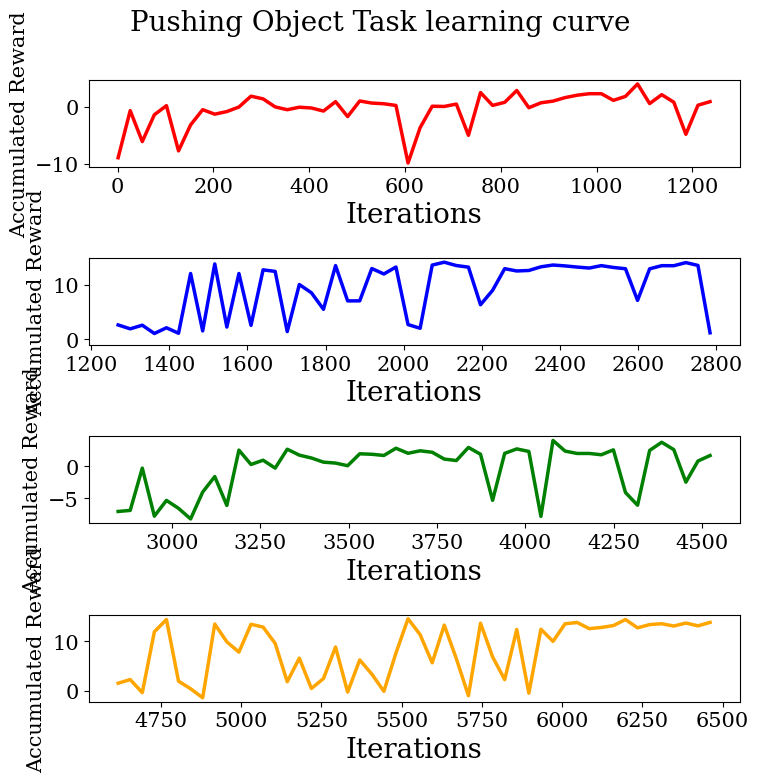

In [87]:
from scipy.interpolate import interp1d

STICK_SIZE=15

def plot_ic(df, ax, target_column="accumulative_objective", low_quantile=0.0, high_quantile=1., use_interpolate=False, color="tab:blue"):
    N_SAMPLE_INTER = 10

    def quantile_low(series):
        return series.quantile(low_quantile)

    def quantile_high(series):
        return series.quantile(high_quantile)

    group_df = df.groupby(["experiment_path", "iteration_id"]).last()
    ic_95_df = group_df.groupby("iteration_id").agg({target_column: [quantile_low, quantile_high]})

    # Plot
    if not use_interpolate:
        X_ = ic_95_df.index
        Y_hi = ic_95_df[target_column].quantile_high
        Y_lo = ic_95_df[target_column].quantile_low
    else:
        cubic_interpolation_model_hi = interp1d(ic_95_df.index, 
                                                ic_95_df[target_column].quantile_high, kind = "cubic")
        
        cubic_interpolation_model_lo = interp1d(ic_95_df.index, 
                                                ic_95_df[target_column].quantile_low, kind = "cubic")
    
        # Plotting the Graph
        X_=np.linspace(ic_95_df.index.min(), ic_95_df.index.max(), N_SAMPLE_INTER)
        Y_hi=cubic_interpolation_model_hi(X_)
        Y_lo=cubic_interpolation_model_lo(X_)
    
    p = ax.fill_between(X_, 
                        Y_hi, Y_lo, 
                        facecolor=color,
                        alpha=0.5)
    ax.tick_params(axis='both', labelsize=STICK_SIZE)
    ax.set_xlabel("Iterations")

def plot_cost_median_learning_curve(df, ax, target_column="accumulative_objective", color=None, use_interpolate=False):
   N_SAMPLE_INTER = 40
   group_df = df.groupby(["experiment_path", "iteration_id"]).last()
   median_df = group_df.groupby("iteration_id").agg({target_column: "median"})

   # Plot
   if not use_interpolate:
      X_ = median_df.index
      Y_ = median_df[target_column]
   else:
      cubic_interpolation_model = interp1d(median_df.index, 
                                           median_df[target_column], 
                                           kind = "cubic")
      
      # Plotting the Graph
      X_ = np.linspace(median_df.index.min(), median_df.index.max(), )
      Y_ = cubic_interpolation_model(X_)

   p = ax.plot(X_, Y_, color=color, lw=2.5)
   ax.set_xlabel("Iterations")
   ax.tick_params(axis='both', labelsize=STICK_SIZE)
   return p[0]

tmp_df = drop_image_columns(df.loc["PPO", "PushingObject"])
tmp_df = tmp_df[["phase", "current_undiscounted_value", "iteration_id", "experiment_path", "trained_task"]]
tmp_df = tmp_df[tmp_df["phase"] == "train"]

print("# trial:", tmp_df.experiment_path.nunique())
fig, ax = plt.subplots(tmp_df["trained_task"].nunique(), figsize=(8, 8))

for subtask_id, subtask in enumerate(tmp_df["trained_task"].unique()):
    plot_ic(tmp_df[tmp_df.trained_task == subtask], 
            ax=ax[subtask_id], 
            use_interpolate=False,
            color=subtask,
            target_column="current_undiscounted_value")
    ax[subtask_id].set_xlabel("Episode", fontsize=20)
    ax[subtask_id].set_ylabel("Accumulated Reward", fontsize=15)
    plot_cost_median_learning_curve(tmp_df[tmp_df.trained_task == subtask], 
            ax=ax[subtask_id], 
            use_interpolate=True,
            color=subtask  if subtask != "yellow" else "orange",
            target_column="current_undiscounted_value")

fig.suptitle("Pushing Object Task learning curve", fontsize=20)
plt.tight_layout()
fig.savefig("./ppo_PO_learning_curve.pdf")

# trial: 1


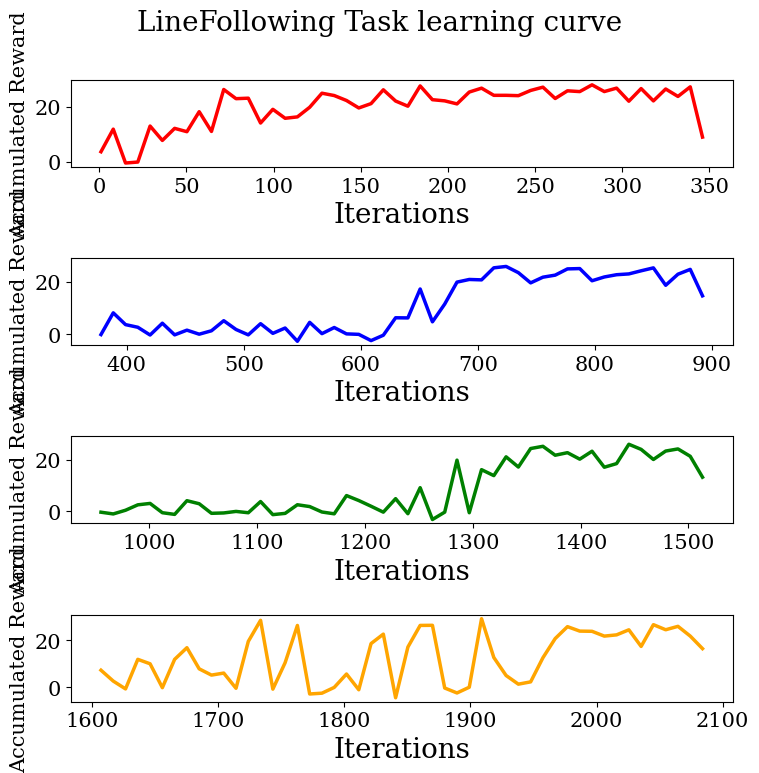

In [88]:
tmp_df = drop_image_columns(df.loc["PPO", "LineFollowing"])
tmp_df = tmp_df[["phase", "current_undiscounted_value", "iteration_id", "experiment_path", "trained_task"]]
tmp_df = tmp_df[tmp_df["phase"] == "train"]

print("# trial:", tmp_df.experiment_path.nunique())
fig, ax = plt.subplots(tmp_df["trained_task"].nunique(), figsize=(8, 8))

for subtask_id, subtask in enumerate(tmp_df["trained_task"].unique()):
    plot_ic(tmp_df[tmp_df.trained_task == subtask], 
            ax=ax[subtask_id], 
            use_interpolate=False,
            color=subtask.split('_')[-1],
            target_column="current_undiscounted_value")
    ax[subtask_id].set_xlabel("Episode", fontsize=20)
    ax[subtask_id].set_ylabel("Accumulated Reward", fontsize=15)
    plot_cost_median_learning_curve(tmp_df[tmp_df.trained_task == subtask], 
            ax=ax[subtask_id], 
            use_interpolate=True,
            color=subtask.split('_')[-1] if subtask.split('_')[-1] != "yellow" else "orange",
            target_column="current_undiscounted_value")

fig.suptitle("LineFollowing Task learning curve", fontsize=20)
plt.tight_layout()
fig.savefig("./ppo_LF_learning_curve.pdf")

# trial: 1


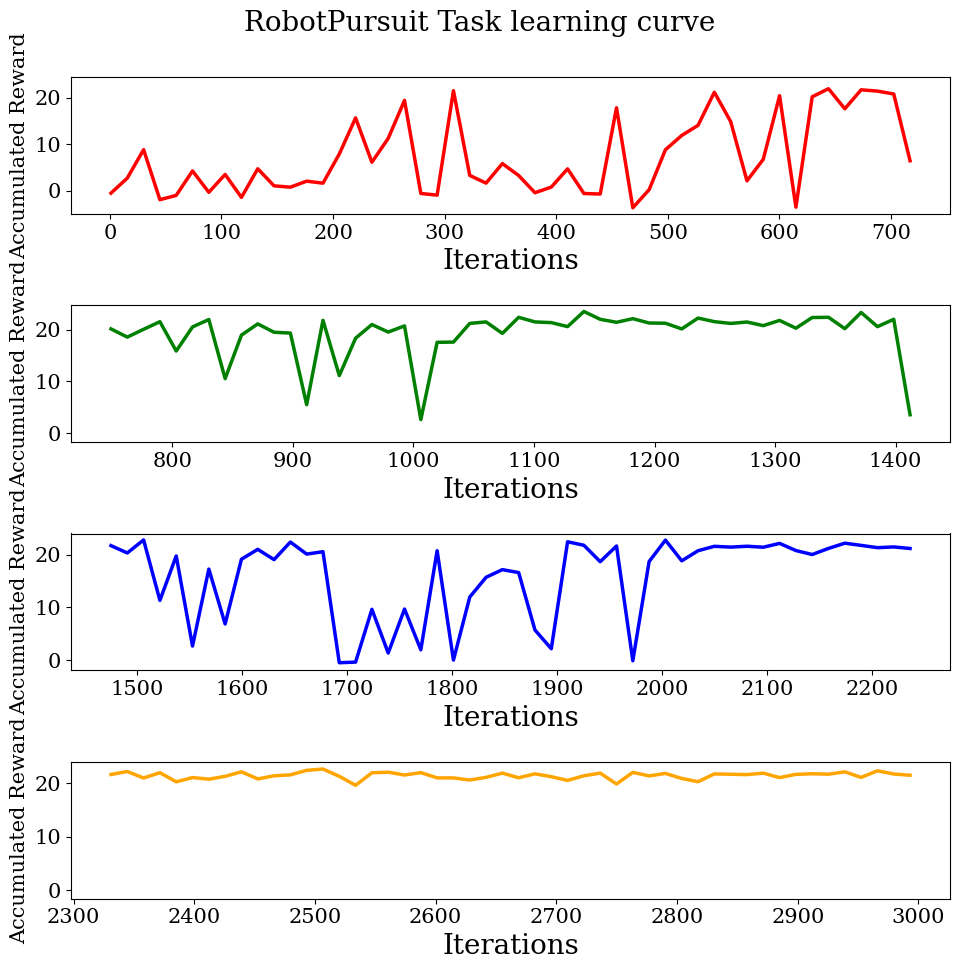

In [89]:
tmp_df = drop_image_columns(df.loc["PPO", "RobotPursuit"])
tmp_df = tmp_df[["phase", "current_undiscounted_value", "iteration_id", "experiment_path", "trained_task"]]
tmp_df = tmp_df[tmp_df["phase"] == "train"]

print("# trial:", tmp_df.experiment_path.nunique())
fig, ax = plt.subplots(tmp_df["trained_task"].nunique(), figsize=(10, 10))

for subtask_id, subtask in enumerate(tmp_df["trained_task"].unique()):
    plot_ic(tmp_df[tmp_df.trained_task == subtask], 
            ax=ax[subtask_id], 
            use_interpolate=False,
            color=subtask.split('_')[0],
            target_column="current_undiscounted_value")
    ax[subtask_id].set_xlabel("Episode", fontsize=20)
    ax[subtask_id].set_ylabel("Accumulated Reward", fontsize=15)
    plot_cost_median_learning_curve(tmp_df[tmp_df.trained_task == subtask], 
            ax=ax[subtask_id], 
            use_interpolate=True,
            color=subtask.split('_')[0] if subtask.split('_')[0] != "yellow" else "orange",
            target_column="current_undiscounted_value")

fig.suptitle("RobotPursuit Task learning curve", fontsize=20)
plt.tight_layout()
fig.savefig("./ppo_RP_learning_curve.pdf")

/tmp/ipykernel_1906977/726900246.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_, Y_, degree)
/tmp/ipykernel_1906977/726900246.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend()
/tmp/ipykernel_1906977/726900246.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_, Y_, degree)
/tmp/ipykernel_1906977/726900246.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend()
/tmp/ipykernel_1906977/726900246.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_, Y_, degree)
/tmp/ipykernel_1906977/726900246.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are

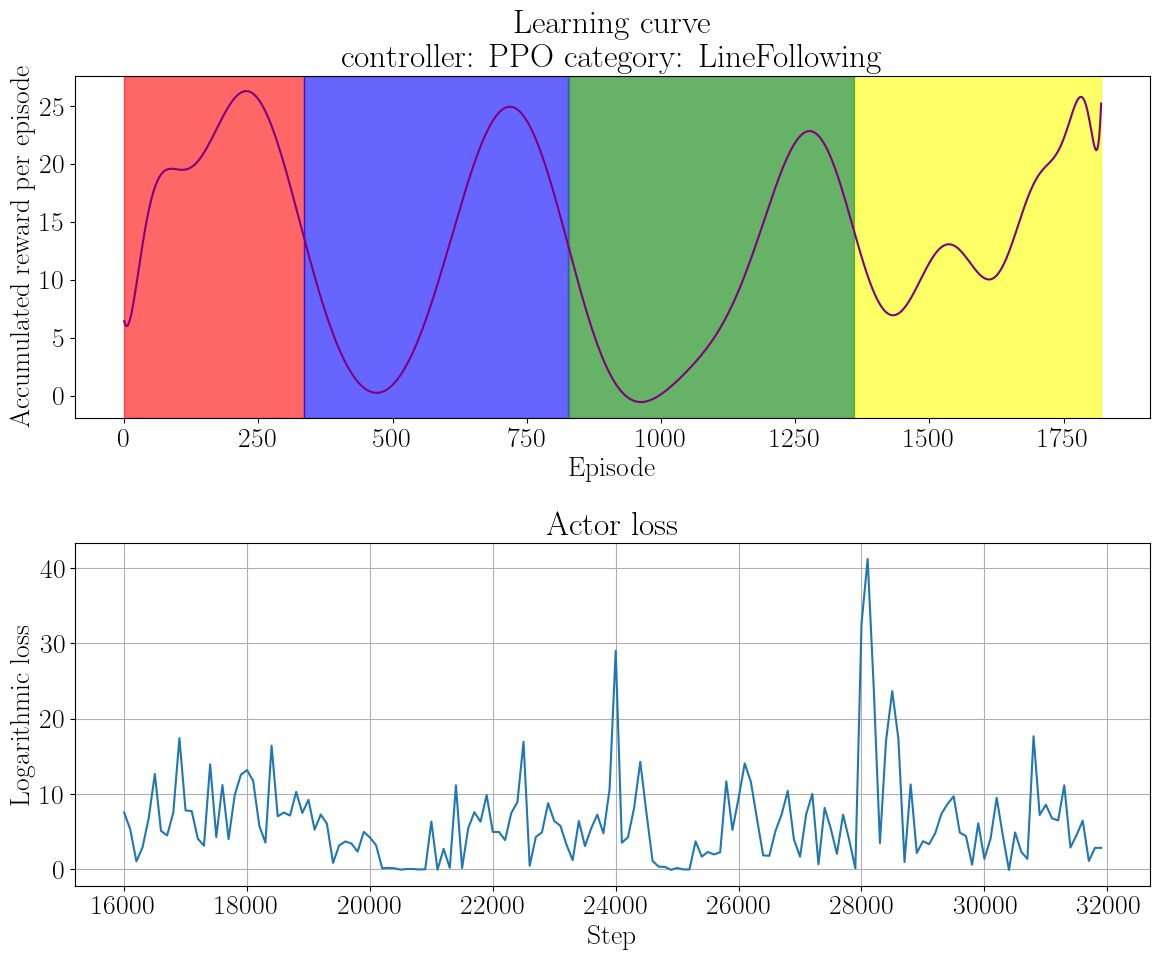

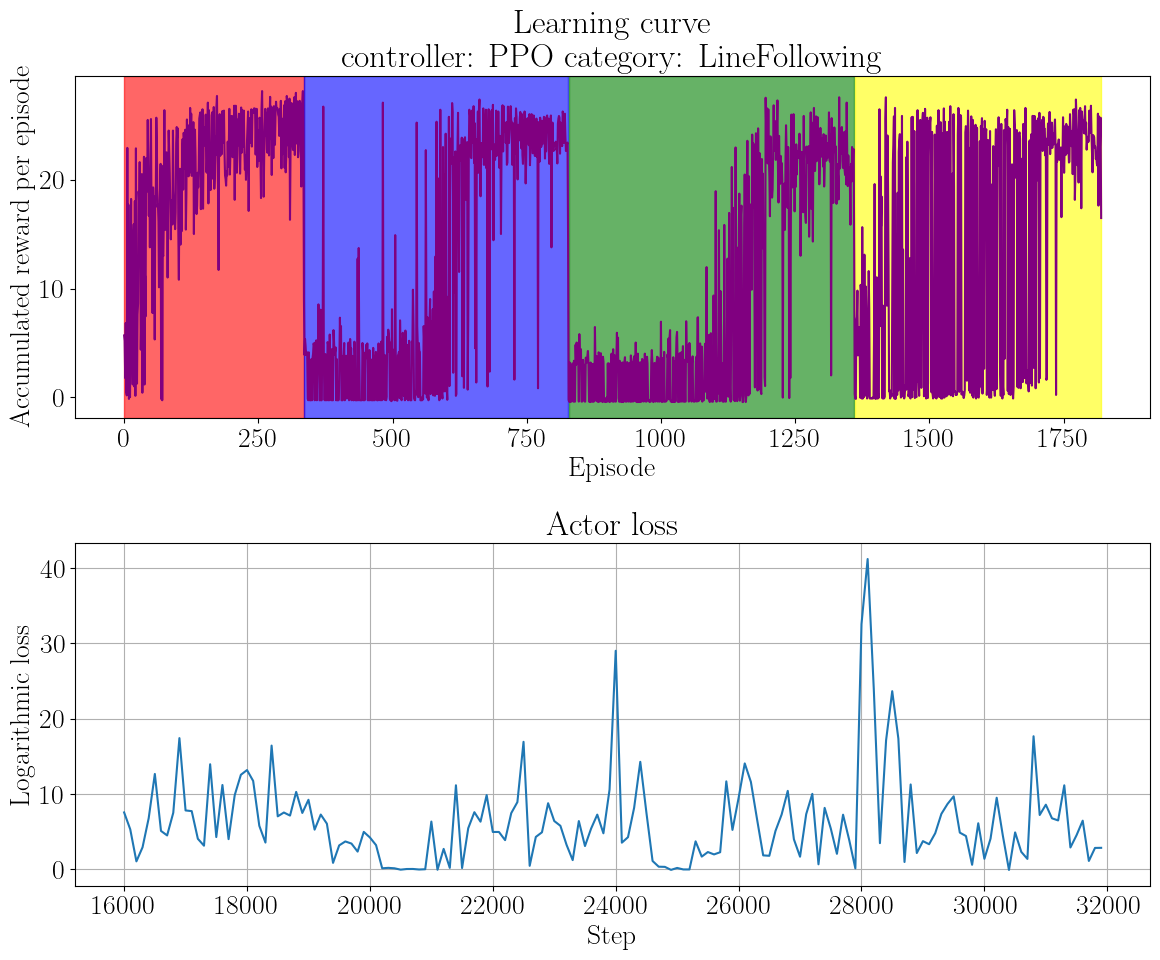

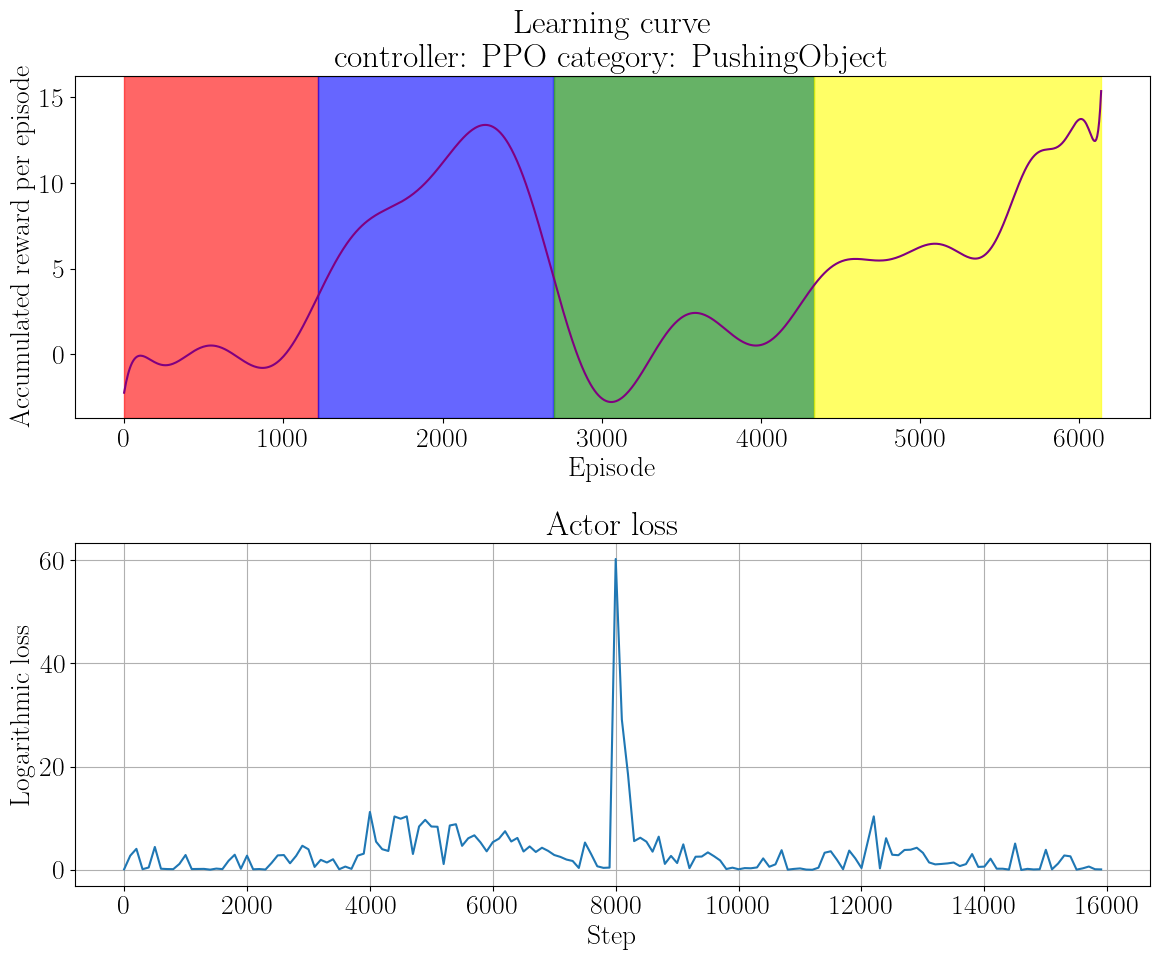

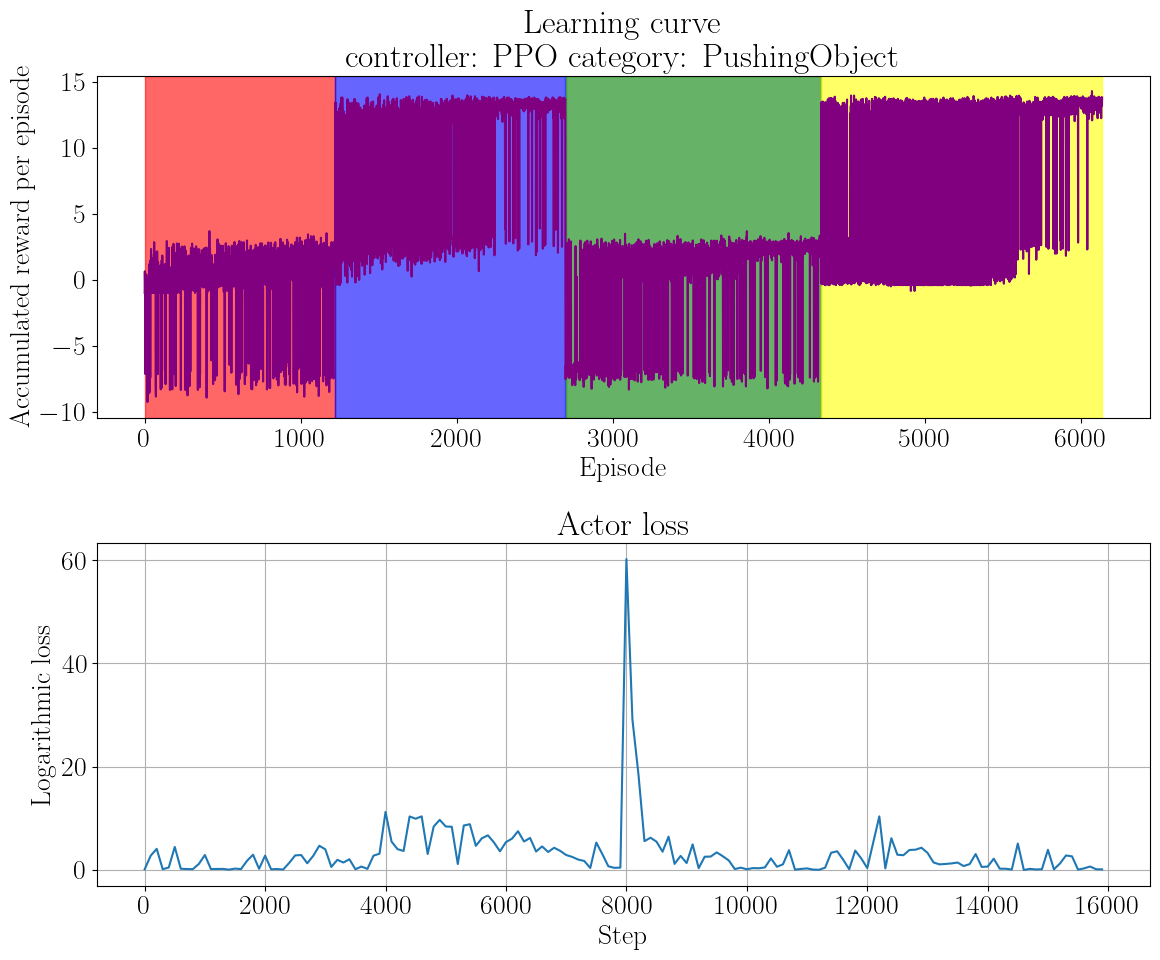

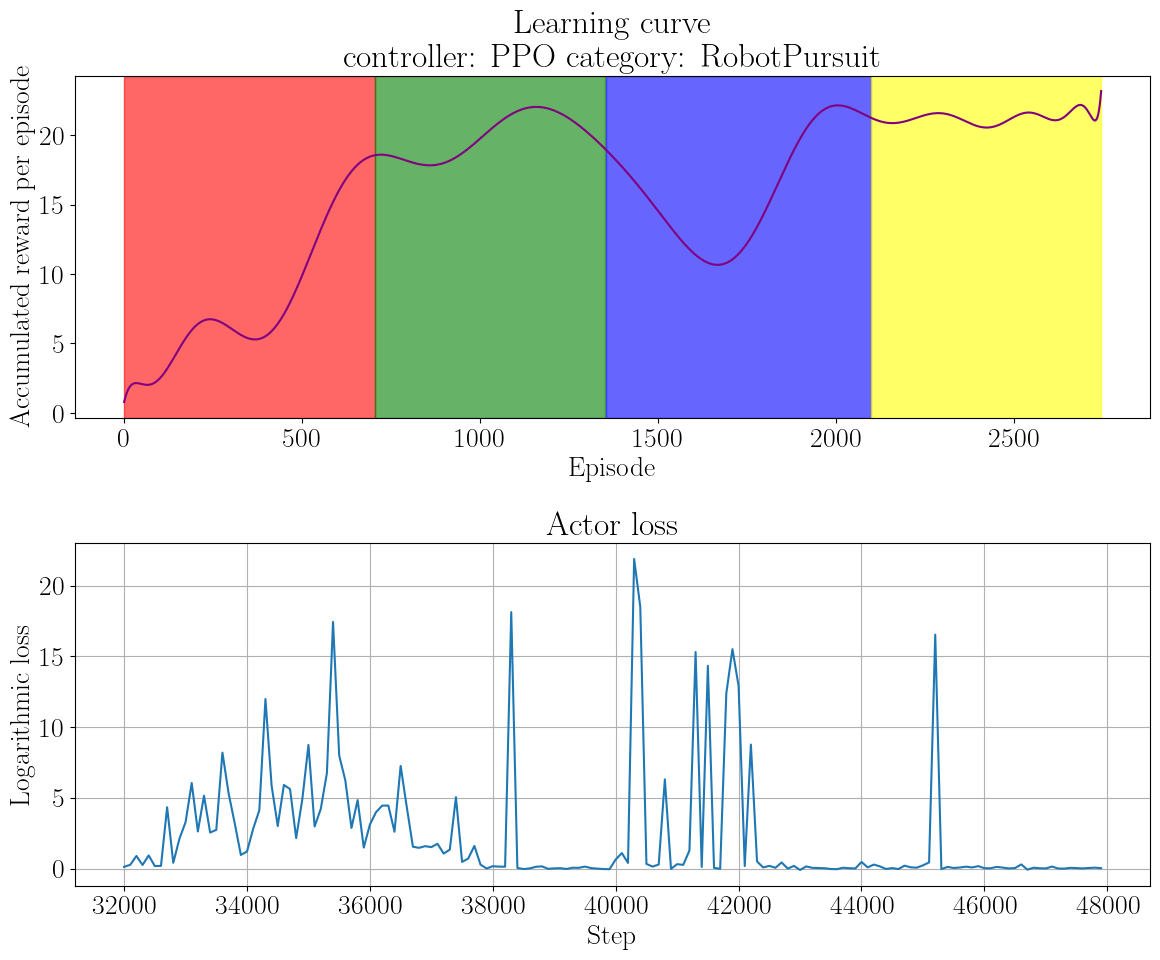

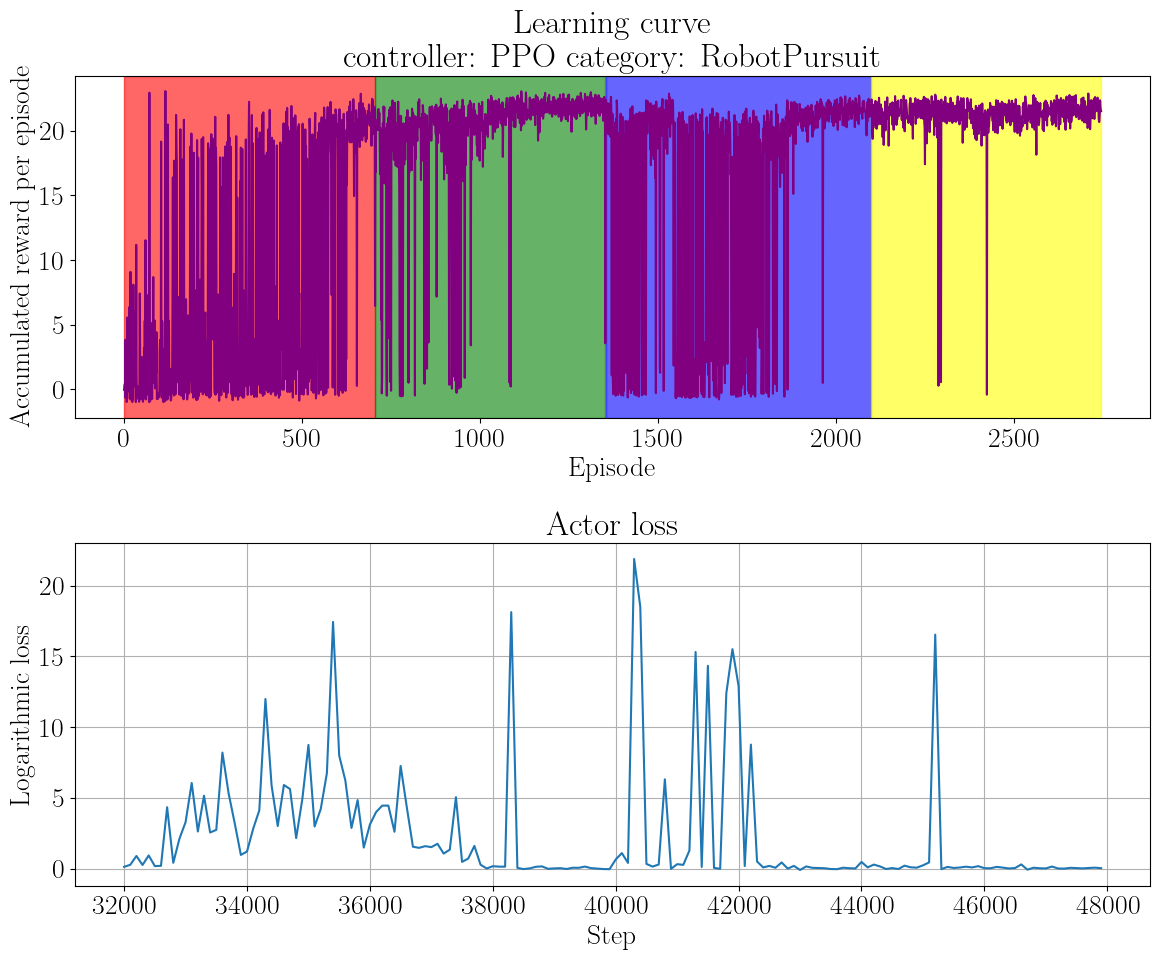

In [90]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20
})
# import matplotlib
# %matplotlib inline

def interpolate(X_, Y_):
    N_SAMPLE_INTER=1000

    degree = 30
    coeffs = np.polyfit(X_, Y_, degree)
    X_ = np.linspace(X_.min(), X_.max(), N_SAMPLE_INTER)
    Y_ = np.polyval(coeffs, X_)

    return X_, Y_

def plot_learning_curve(index, index_names, df, title="Learning curve", ax=None, use_interpolate=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    df["learning_starts"] = 250
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index

    if not use_interpolate:
        tmp_group_df = tmp_group_df.set_index("iteration_id")
        tmp_group_df.plot(y="current_undiscounted_value", ax=ax, color="purple")
    else:
        ax.plot(*interpolate(tmp_group_df.iteration_id, tmp_group_df.current_undiscounted_value), color="purple")
        

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.6, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()

    return "_".join([f"{a}_{b}" for a, b in list(zip(index_names, index))]) + "_interp_{}".format(1 if use_interpolate else 0)


for id in group_df.index:
    for interp in [True, False]:
        fig, ax = plt.subplots(2, 1, figsize=(12, 10))
        title = plot_learning_curve(id, 
                                    group_df.index.names, 
                                    df[df.phase=="train"], 
                                    ax=ax[0],
                                    use_interpolate=interp)
        
        tmp_df = df.reset_index().set_index(group_df.index.names)
        tmp_df = tmp_df.loc[id]

        actor_df["steps"] = [100 * i for i in range(len(actor_df))]
        actor_df[actor_df.experiment_path == tmp_df.experiment_path.values[0]].plot(x="steps", 
                                                                                y="actor_loss", 
                                                                                ax=ax[1])
        ax[1].set_title("Actor loss")
        ax[1].set_ylabel("Logarithmic loss")
        ax[1].set_xlabel("Step")
        ax[1].legend().remove()
        ax[1].grid()
        # plot_learning_curve(group_df.index[1], group_df.index.names, df)
        # plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
        # plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
        # plt.show()
        plt.tight_layout()
        os.makedirs("./media", exist_ok=True)
        fig.savefig("./media/{}.pdf".format(title))

In [91]:
df[df.phase=="train"].set_index("iteration_id").current_undiscounted_value.values[-30:]

array([ 0.35      ,  0.875     ,  1.60357143,  2.51895604,  3.37895604,
        4.28895604,  5.27986513,  6.12060588,  6.97867039,  7.86647527,
        8.82137723,  9.81683178, 10.71683178, 11.62433178, 21.62433178,
        0.35      ,  0.875     ,  1.575     ,  2.49038462,  3.40371795,
        4.36254148,  5.18981421,  6.0824068 ,  7.04047131,  7.84797131,
        8.76397131,  9.7285867 , 10.66004737, 11.53246117, 21.53246117])

In [92]:
df = df.reset_index()
df[df.iteration_id==1]

,controller,category,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,...,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,global_step,trained_task
0,PPO,LineFollowing,0,0.000,0.489796,None,0.489796,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,0,circle_red
1,PPO,LineFollowing,1,0.000,0.489796,None,0.979592,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,1,circle_red
2,PPO,LineFollowing,2,0.198,0.448980,None,1.428571,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,2,circle_red
3,PPO,LineFollowing,3,0.363,0.367347,None,1.795918,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,3,circle_red
4,PPO,LineFollowing,4,0.528,0.326531,None,2.122449,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,4,circle_red
5,PPO,LineFollowing,5,0.693,0.367347,None,2.489796,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,5,circle_red
6,PPO,LineFollowing,6,0.858,0.408163,None,2.897959,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,6,circle_red
7,PPO,LineFollowing,7,1.023,0.408163,None,3.306122,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,7,circle_red
8,PPO,LineFollowing,8,1.188,0.367347,None,3.673469,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,8,circle_red
9,PPO,LineFollowing,9,1.353,0.285714,None,3.959184,1,1,circle_red,...,NaN,NaN,NaN,NaN,NaN,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,9,circle_red


In [93]:
df.running_objective.describe()

count    133333.000000
mean          0.831218
std           1.925235
min         -10.000000
25%           0.367347
50%           0.653061
75%           0.864000
max          10.000000
Name: running_objective, dtype: float64

In [94]:
def postprocess_linefollowing(df):
    if not df.index.is_integer():
        df = df.reset_index()

    df["catch_the_line"] = df.running_objective.apply(lambda x: x > 0.7)
    return df

In [95]:
df = postprocess_linefollowing(df)

analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

if "catch_the_line" in df.columns:
    agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
    agg['catch_the_line'] = 'sum'

    analyse_group_df = analyse_group_df.agg(agg)
else:
    analyse_group_df = analyse_group_df.last()

analyse_group_df

/tmp/ipykernel_1906977/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Angular Velocity [rad/s]  Image pixel 0  \
task_name       iteration_id                                           
blue            2816                   tensor(1.9300)       0.286275   
                2817                   tensor(1.1566)       0.286275   
                2818                   tensor(2.2554)       0.286275   
                2819                   tensor(0.1347)       0.286275   
                2820                   tensor(0.8639)       0.286275   
...                                               ...            ...   
yellow_cylinder 3113                  tensor(-0.8791)       0.854902   
                3114                  tensor(-1.2879)       0.854902   
                3115                  tensor(-2.4319)       0.843137   
                3116                  tensor(-1.5747)       0.858824   
                3117                   tensor(3.2694)       0.854902   

                              Image pixel 1  Image pixel 10  Image pixel 100  \
task_name       iteration_id                                                   
blue            2816               0.286275        0.286275         0.286275   
                2817               0.286275        0.286275         0.286275   
                2818               0.286275        0.286275         0.286275   
                2819               0.286275        0.286275         0.286275   
                2820               0.286275        0.286275         0.286275   
...                                     ...             ...              ...   
yellow_cylinder 3113               0.854902        0.854902         0.850980   
                3114               0.854902        0.854902         0.847059   
                3115               0.843137        0.839216         0.854902   
                3116               0.858824        0.843137         0.854902   
                3117               0.854902        0.854902         0.819608   

                              Image pixel 1000  Image pixel 1001  \
task_name       iteration_id                                       
blue            2816                  0.286275          0.749020   
                2817                  0.286275          0.749020   
                2818                  0.286275          0.749020   
                2819                  0.286275          0.749020   
                2820                  0.286275          0.749020   
...                                        ...               ...   
yellow_cylinder 3113                  0.290196          0.290196   
                3114                  0.290196          0.290196   
                3115                  0.290196          0.290196   
                3116                  0.290196          0.290196   
                3117                  0.290196          0.290196   

                              Image pixel 1002  Image pixel 1003  \
task_name       iteration_id                                       
blue            2816                  0.286275          0.286275   
                2817                  0.286275          0.286275   
                2818                  0.286275          0.286275   
                2819                  0.286275          0.286275   
                2820                  0.286275          0.286275   
...                                        ...               ...   
yellow_cylinder 3113                  0.290196          0.290196   
                3114                  0.290196          0.290196   
                3115                  0.290196          0.290196   
                3116                  0.290196          0.290196   
                3117                  0.290196          0.290196   

                              Image pixel 1004  ...  exploration  global_step  \
task_name       iteration_id                    ...                             
blue            2816                  0.749020  ...        False        20394   
                2817                  

# Evaluation

In [96]:
def experiment_sort_index(index):
    print(index)
    if index.name == "category":
        category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]nt(index)
    # if index.name == "category":
    #     category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]
    
    if index.name in ["trained_task", "task_name"]:
        lf_list = ["circle_red", "circle_blue", "circle_green", "circle_yellow"]
        rp_list = ["red_cube", "green_capsule", "blue_sphere", "yellow_cylinder"]
        po_list = ["red", "blue", "green", "yellow"]

        common_list = lf_list + rp_list + po_list
        return [common_list.index(n) for n in index]
    
    return [a for a in index]

In [97]:
analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
agg['catch_the_line'] = 'sum'
analyse_group_df = analyse_group_df.agg(agg)
pd.__version__

'2.2.3'

In [98]:
df = postprocess_linefollowing(df)

def pivot_success(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        # analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'trained_task'],
            index=["category", "task_name"], 
            values="completion", aggfunc=aggregate_function
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None
    
    return pivot_table

def pivot_avg(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        # analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'trained_task'],
            index=["category", "task_name"], 
            values="current_undiscounted_value", aggfunc="mean"
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None

    return pivot_table

pivot_success(df)

/tmp/ipykernel_1906977/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing',
       'PushingObject', 'PushingObject', 'PushingObject', 'PushingObject',
       'RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'],
      dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow', 'blue',
       'green', 'red', 'yellow', 'blue_sphere', 'green_capsule', 'red_cube',
       'yellow_cylinder'],
      dtype='object', name='task_name')
Index(['PPO', 'PPO', 'PPO', 'PPO', 'PPO', 'PPO', 'PPO', 'PPO', 'PPO', 'PPO',
       'PPO', 'PPO'],
      dtype='object', name='controller')
Index(['blue', 'blue_sphere', 'circle_blue', 'circle_green', 'circle_red',
       'circle_yellow', 'green', 'green_capsule', 'red', 'red_cube', 'yellow',
       'yellow_cylinder'],
      dtype='object', name='trained_task')


controller                                PPO                                  \
trained_task                       circle_red     circle_blue    circle_green   
category      task_name                                                         
LineFollowing circle_red       22 / 30 = 0.73  14 / 30 = 0.47  00 / 30 = 0.00   
              circle_blue                 NaN  27 / 30 = 0.90  18 / 30 = 0.60   
              circle_green                NaN             NaN  02 / 30 = 0.07   
              circle_yellow               NaN             NaN             NaN   
PushingObject red                         NaN             NaN             NaN   
              blue                        NaN             NaN             NaN   
              green                       NaN             NaN             NaN   
              yellow                      NaN             NaN             NaN   
RobotPursuit  red_cube                    NaN             NaN             NaN   
              green_capsule               NaN             NaN             NaN   
              blue_sphere                 NaN             NaN             NaN   
              yellow_cylinder             NaN             NaN             NaN   

controller                                                                     \
trained_task                    circle_yellow        red_cube   green_capsule   
category      task_name                                                         
LineFollowing circle_red       00 / 30 = 0.00             NaN             NaN   
              circle_blue      08 / 30 = 0.27             NaN             NaN   
              circle_green     00 / 30 = 0.00             NaN             NaN   
              circle_yellow    14 / 30 = 0.47             NaN             NaN   
PushingObject red                         NaN             NaN             NaN   
              blue                        NaN             NaN             NaN   
              green                       NaN             NaN             NaN   
              yellow                      NaN             NaN             NaN   
RobotPursuit  red_cube                    NaN  30 / 30 = 1.00  30 / 30 = 1.00   
              green_capsule               NaN             NaN  30 / 30 = 1.00   
              blue_sphere                 NaN             NaN             NaN   
              yellow_cylinder             NaN             NaN             NaN   

controller                                                                     \
trained_task                      blue_sphere yellow_cylinder             red   
category      task_name                                                         
LineFollowing circle_red                  NaN             NaN             NaN   
              circle_blue                 NaN             NaN             NaN   
              circle_green                NaN             NaN             NaN   
              circle_yellow               NaN             NaN             NaN   
PushingObject red                         NaN             NaN  29 / 30 = 0.97   
              blue                        NaN             NaN             NaN   
              green                       NaN             NaN             NaN   
              yellow                      NaN             NaN             NaN   
RobotPursuit  red_cube         30 / 30 = 1.00  30 / 30 = 1.00             NaN   
              green_capsule    30 / 30 = 1.00  30 / 30 = 1.00             NaN   
              blue_sphere      30 / 30 = 1.00  30 / 30 = 1.00             NaN   
              yellow_cylinder             NaN  30 / 30 = 1.00             NaN   

controller                                                                     
trained_task                             blue           green          yellow  
category      task_name                                                        
LineFollowing circle_red                  NaN             NaN             NaN  
              circle_blue       

In [99]:
sssdsdadsadasapivot_success(df[df.category == "RobotPursuit"])

NameError: name 'sssdsdadsadasapivot_success' is not defined

In [24]:
pivot_avg(df[df.category == "RobotPursuit"])

Index(['RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'], dtype='object', name='category')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='task_name')
Index(['PPO', 'PPO', 'PPO', 'PPO'], dtype='object', name='controller')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='trained_task')


controller                          PPO                            \
trained_task                   red_cube green_capsule blue_sphere   
category     task_name                                              
RobotPursuit red_cube         20.867706     16.925784   20.665013   
             green_capsule          NaN     12.875505   19.580558   
             blue_sphere            NaN           NaN   18.654088   
             yellow_cylinder        NaN           NaN         NaN   

controller                                    
trained_task                 yellow_cylinder  
category     task_name                        
RobotPursuit red_cube              21.575972  
             green_capsule         21.800296  
             blue_sphere           18.766046  
             yellow_cylinder       21.665055

In [25]:
# pivot_avg(df)
pivot_success(df[df.category == "LineFollowing"])

Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['PPO', 'PPO', 'PPO', 'PPO'], dtype='object', name='controller')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='trained_task')


controller                              PPO                                  \
trained_task                     circle_red     circle_blue    circle_green   
category      task_name                                                       
LineFollowing circle_red     13 / 20 = 0.65  16 / 20 = 0.80  00 / 20 = 0.00   
              circle_blue               NaN  09 / 20 = 0.45  10 / 20 = 0.50   
              circle_green              NaN             NaN  00 / 20 = 0.00   
              circle_yellow             NaN             NaN             NaN   

controller                                   
trained_task                  circle_yellow  
category      task_name                      
LineFollowing circle_red     10 / 20 = 0.50  
              circle_blue    08 / 20 = 0.40  
              circle_green   03 / 20 = 0.15  
              circle_yellow  09 / 20 = 0.45

In [26]:
pivot_avg(df[df.category == "LineFollowing"])

Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['PPO', 'PPO', 'PPO', 'PPO'], dtype='object', name='controller')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='trained_task')


controller                         PPO                                       
trained_task                circle_red circle_blue circle_green circle_yellow
category      task_name                                                      
LineFollowing circle_red      23.77551   23.970408     3.143878     13.475510
              circle_blue          NaN   11.786735    14.225510     10.926531
              circle_green         NaN         NaN     6.393878      8.674490
              circle_yellow        NaN         NaN          NaN     11.862245

In [27]:
pivot_success(df[df.category == "PushingObject"])

Index(['PushingObject', 'PushingObject', 'PushingObject', 'PushingObject'], dtype='object', name='category')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='task_name')
Index(['PPO', 'PPO', 'PPO', 'PPO'], dtype='object', name='controller')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='trained_task')


controller                          PPO                                  \
trained_task                        red            blue           green   
category      task_name                                                   
PushingObject red        18 / 20 = 0.90  06 / 20 = 0.30  17 / 20 = 0.85   
              blue                  NaN  13 / 20 = 0.65  03 / 20 = 0.15   
              green                 NaN             NaN  16 / 20 = 0.80   
              yellow                NaN             NaN             NaN   

controller                               
trained_task                     yellow  
category      task_name                  
PushingObject red        11 / 20 = 0.55  
              blue       16 / 20 = 0.80  
              green      04 / 20 = 0.20  
              yellow     12 / 20 = 0.60

In [28]:
pivot_avg(df[df.category == "PushingObject"])

Index(['PushingObject', 'PushingObject', 'PushingObject', 'PushingObject'], dtype='object', name='category')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='task_name')
Index(['PPO', 'PPO', 'PPO', 'PPO'], dtype='object', name='controller')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='trained_task')


controller                   PPO                               
trained_task                 red      blue     green     yellow
category      task_name                                        
PushingObject red        0.08639 -5.057072 -0.366656  -2.541861
              blue           NaN  8.302415  2.533593  10.389264
              green          NaN       NaN -1.045876  -5.710057
              yellow         NaN       NaN       NaN   7.913975